In [72]:

# Which top and bottom 5 EU countries have the most and least train freight?

import pandas as pd
import matplotlib.pyplot as plt

# Loading the dataset
data = pd.read_csv("../Processed/merged_eurostat_clean.csv")


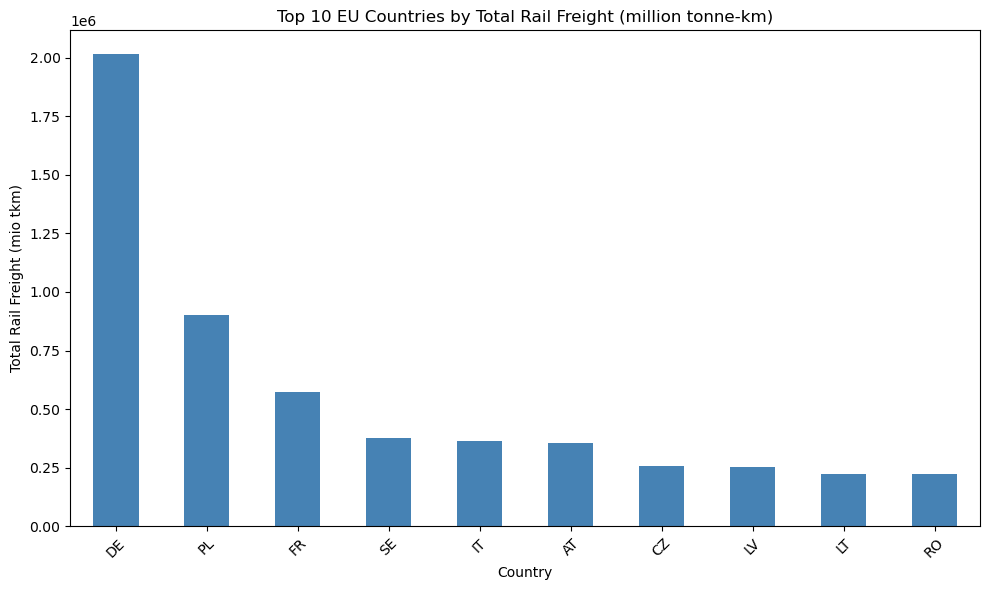

In [73]:
# Top 10 EU Countries by Total Rail Freight (million tonne-km)
data['geo'] = data['geo'].astype(str).str.strip().str.upper()
data['rail_f_total_Nat&INT_mio_tkm'] = pd.to_numeric(
    data['rail_f_total_Nat&INT_mio_tkm'], errors='coerce'
).fillna(0)

# Aggregating total rail freight by country
country_totals = (
    data.groupby('geo')['rail_f_total_Nat&INT_mio_tkm']
    .sum()
    .sort_values(ascending=False)
)

# Plotting top 10 countries
plt.figure(figsize=(10,6))
country_totals.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 EU Countries by Total Rail Freight (million tonne-km)')
plt.xlabel('Country')
plt.ylabel('Total Rail Freight (mio tkm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

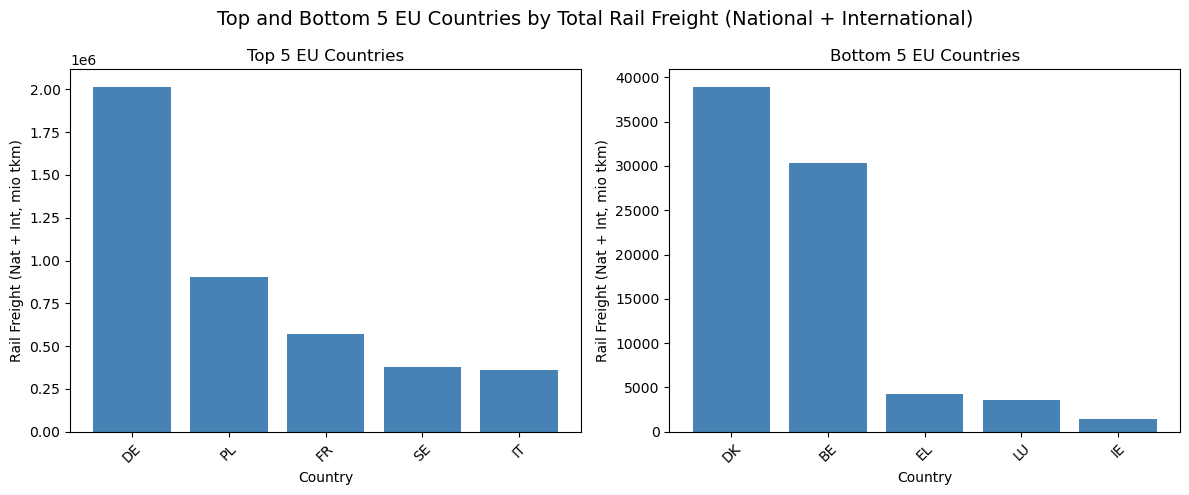

In [74]:
# Aggregating total freight (Nat + Int) per country
country_totals = (
    data.groupby('geo')['rail_f_total_Nat&INT_mio_tkm']
    .sum()
    .sort_values(ascending=False)
)

# Identifying top 5 and bottom 5 countries
top5 = country_totals.head(5)
bottom5 = country_totals.tail(5)

# Plot side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Top 5
axes[0].bar(top5.index, top5.values, color='steelblue')
axes[0].set_title('Top 5 EU Countries')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Rail Freight (Nat + Int, mio tkm)')
axes[0].tick_params(axis='x', rotation=45)

# Bottom 5
axes[1].bar(bottom5.index, bottom5.values, color='steelblue')
axes[1].set_title('Bottom 5 EU Countries')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Rail Freight (Nat + Int, mio tkm)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Top and Bottom 5 EU Countries by Total Rail Freight (National + International)', fontsize=14)
plt.tight_layout()
plt.show()

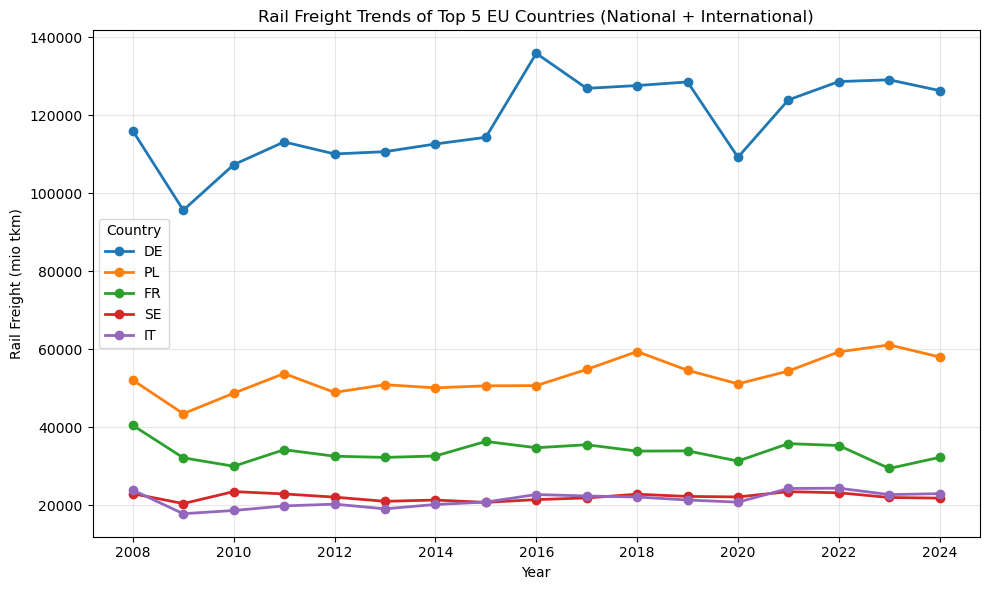

In [75]:
#Identifying top 5 countries ---
top5_countries = country_totals.head(5).index

#Filtering dataset for top 5 and aggregate by year
trend = (
    data[data['geo'].isin(top5_countries)]
    .groupby(['TIME_PERIOD', 'geo'])['rail_f_total_Nat&INT_mio_tkm']
    .sum()
    .reset_index()
)

# Plotting trend lines
plt.figure(figsize=(10,6))
for country in top5_countries:
    subset = trend[trend['geo'] == country]
    plt.plot(subset['TIME_PERIOD'], subset['rail_f_total_Nat&INT_mio_tkm'],
             marker='o', linewidth=2, label=country)

plt.title('Rail Freight Trends of Top 5 EU Countries (National + International)')
plt.xlabel('Year')
plt.ylabel('Rail Freight (mio tkm)')
plt.legend(title='Country')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\prans\AppData\Local\Temp\ipykernel_10464\1857452225.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


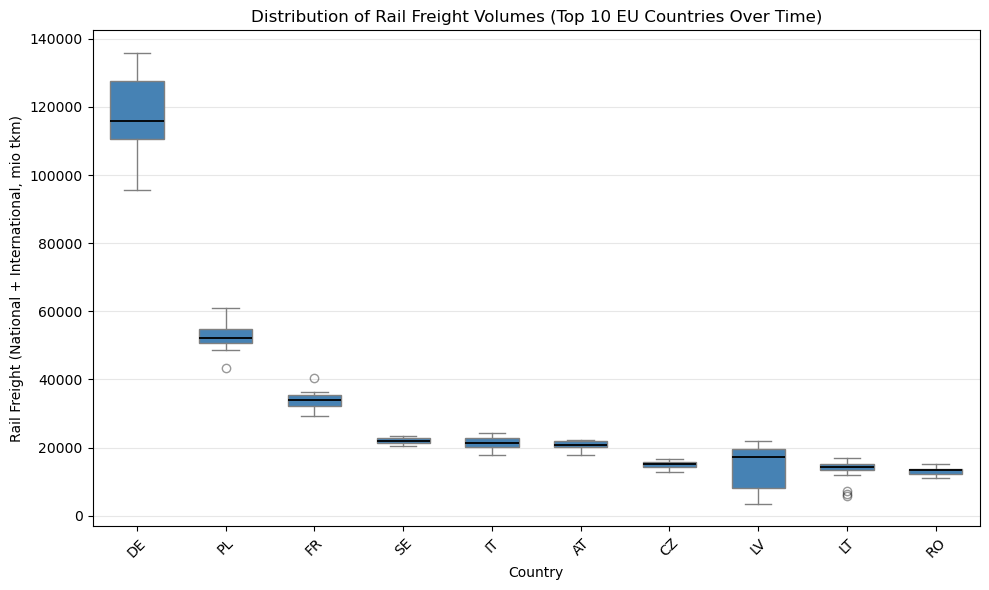

In [76]:
top10_countries = country_totals.head(10).index

# Filtering dataset for top 10 
top10_data = data[data['geo'].isin(top10_countries)]

# Creating boxplot
box_data = [top10_data[top10_data['geo'] == country]['rail_f_total_Nat&INT_mio_tkm'] for country in top10_countries]

# Plot boxplot
plt.figure(figsize=(10,6))
bp = plt.boxplot(
    box_data,
    labels=top10_countries,
    patch_artist=True,
    widths=0.6,
    medianprops=dict(color='black', linewidth=1.3),
    boxprops=dict(facecolor='steelblue', color='gray'),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray'),
    flierprops=dict(marker='o', color='gray', alpha=0.4)
)

plt.title('Distribution of Rail Freight Volumes (Top 10 EU Countries Over Time)')
plt.xlabel('Country')
plt.ylabel('Rail Freight (National + International, mio tkm)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
## Chi-Square Goodness-of-Fit Test
from scipy.stats import chisquare
observed = country_totals.values
expected = [country_totals.mean()] * len(country_totals)

# --- Performing Chi-Square test ---
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-Square Statistic:", round(chi2_stat, 2))
print("P-Value:", p_value)

# --- Interpretation ---
if p_value < 0.05:
    print("\nResult: Reject H₀ → Freight distribution is NOT uniform across EU countries.")
else:
    print("\nResult: Fail to reject H₀ → Freight distribution appears uniform.")

Chi-Square Statistic: 15767985.31
P-Value: 0.0

Result: Reject H₀ → Freight distribution is NOT uniform across EU countries.


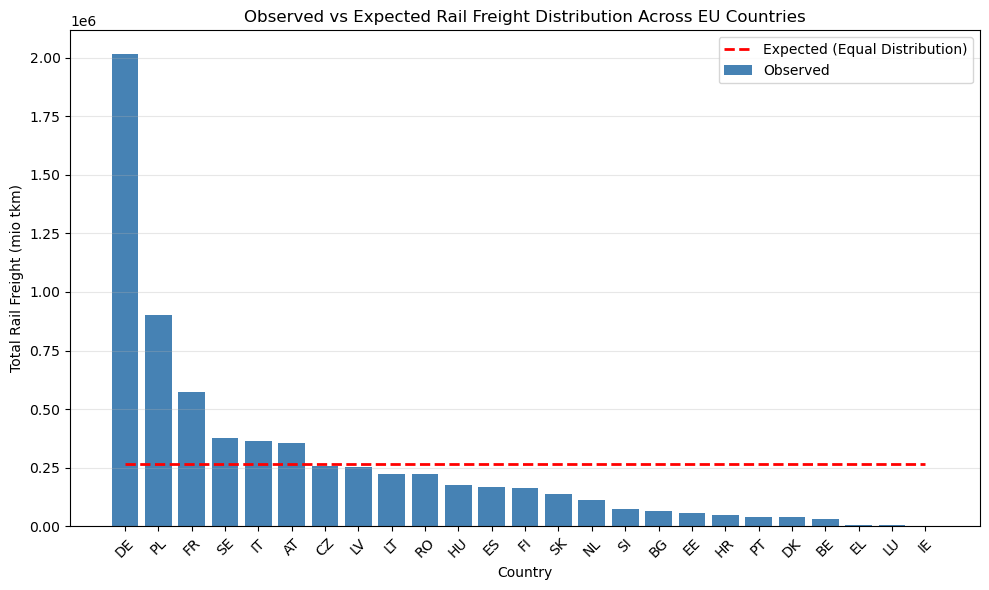

In [78]:
# --- Expected equal distribution ---
expected = [country_totals.mean()] * len(country_totals)

# --- Creating  observed vs. expected bar chart ---
plt.figure(figsize=(10,6))
plt.bar(country_totals.index, country_totals.values, color='steelblue', label='Observed')
plt.plot(country_totals.index, expected, 'r--', label='Expected (Equal Distribution)', linewidth=2)

plt.title('Observed vs Expected Rail Freight Distribution Across EU Countries')
plt.xlabel('Country')
plt.ylabel('Total Rail Freight (mio tkm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()